# Data Analysis

In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data_train = pd.read_csv('data/X_train.csv')
data_train.head()

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [5]:
# Check for missing values
missing_values = data_train.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")
print(f"\nTotal missing values: {missing_values.sum()}")
print(f"Percentage of missing data: {(missing_values.sum() / (data_train.shape[0] * data_train.shape[1]) * 100):.2f}%")

Missing Values per Column:
RET_20                       58
RET_19                       50
RET_18                       42
RET_17                       34
RET_16                       26
RET_15                       18
RET_14                       13
RET_13                        9
RET_12                        6
RET_11                        4
RET_10                        2
SIGNED_VOLUME_20           8498
SIGNED_VOLUME_19           3002
SIGNED_VOLUME_18            859
SIGNED_VOLUME_17             58
SIGNED_VOLUME_16             50
SIGNED_VOLUME_15             42
SIGNED_VOLUME_14             34
SIGNED_VOLUME_13             26
SIGNED_VOLUME_12             18
SIGNED_VOLUME_11             13
SIGNED_VOLUME_10              9
SIGNED_VOLUME_9               6
SIGNED_VOLUME_8               4
SIGNED_VOLUME_7               2
SIGNED_VOLUME_1          387506
MEDIAN_DAILY_TURNOVER      3638
dtype: int64

Total missing values: 404027
Percentage of missing data: 1.70%


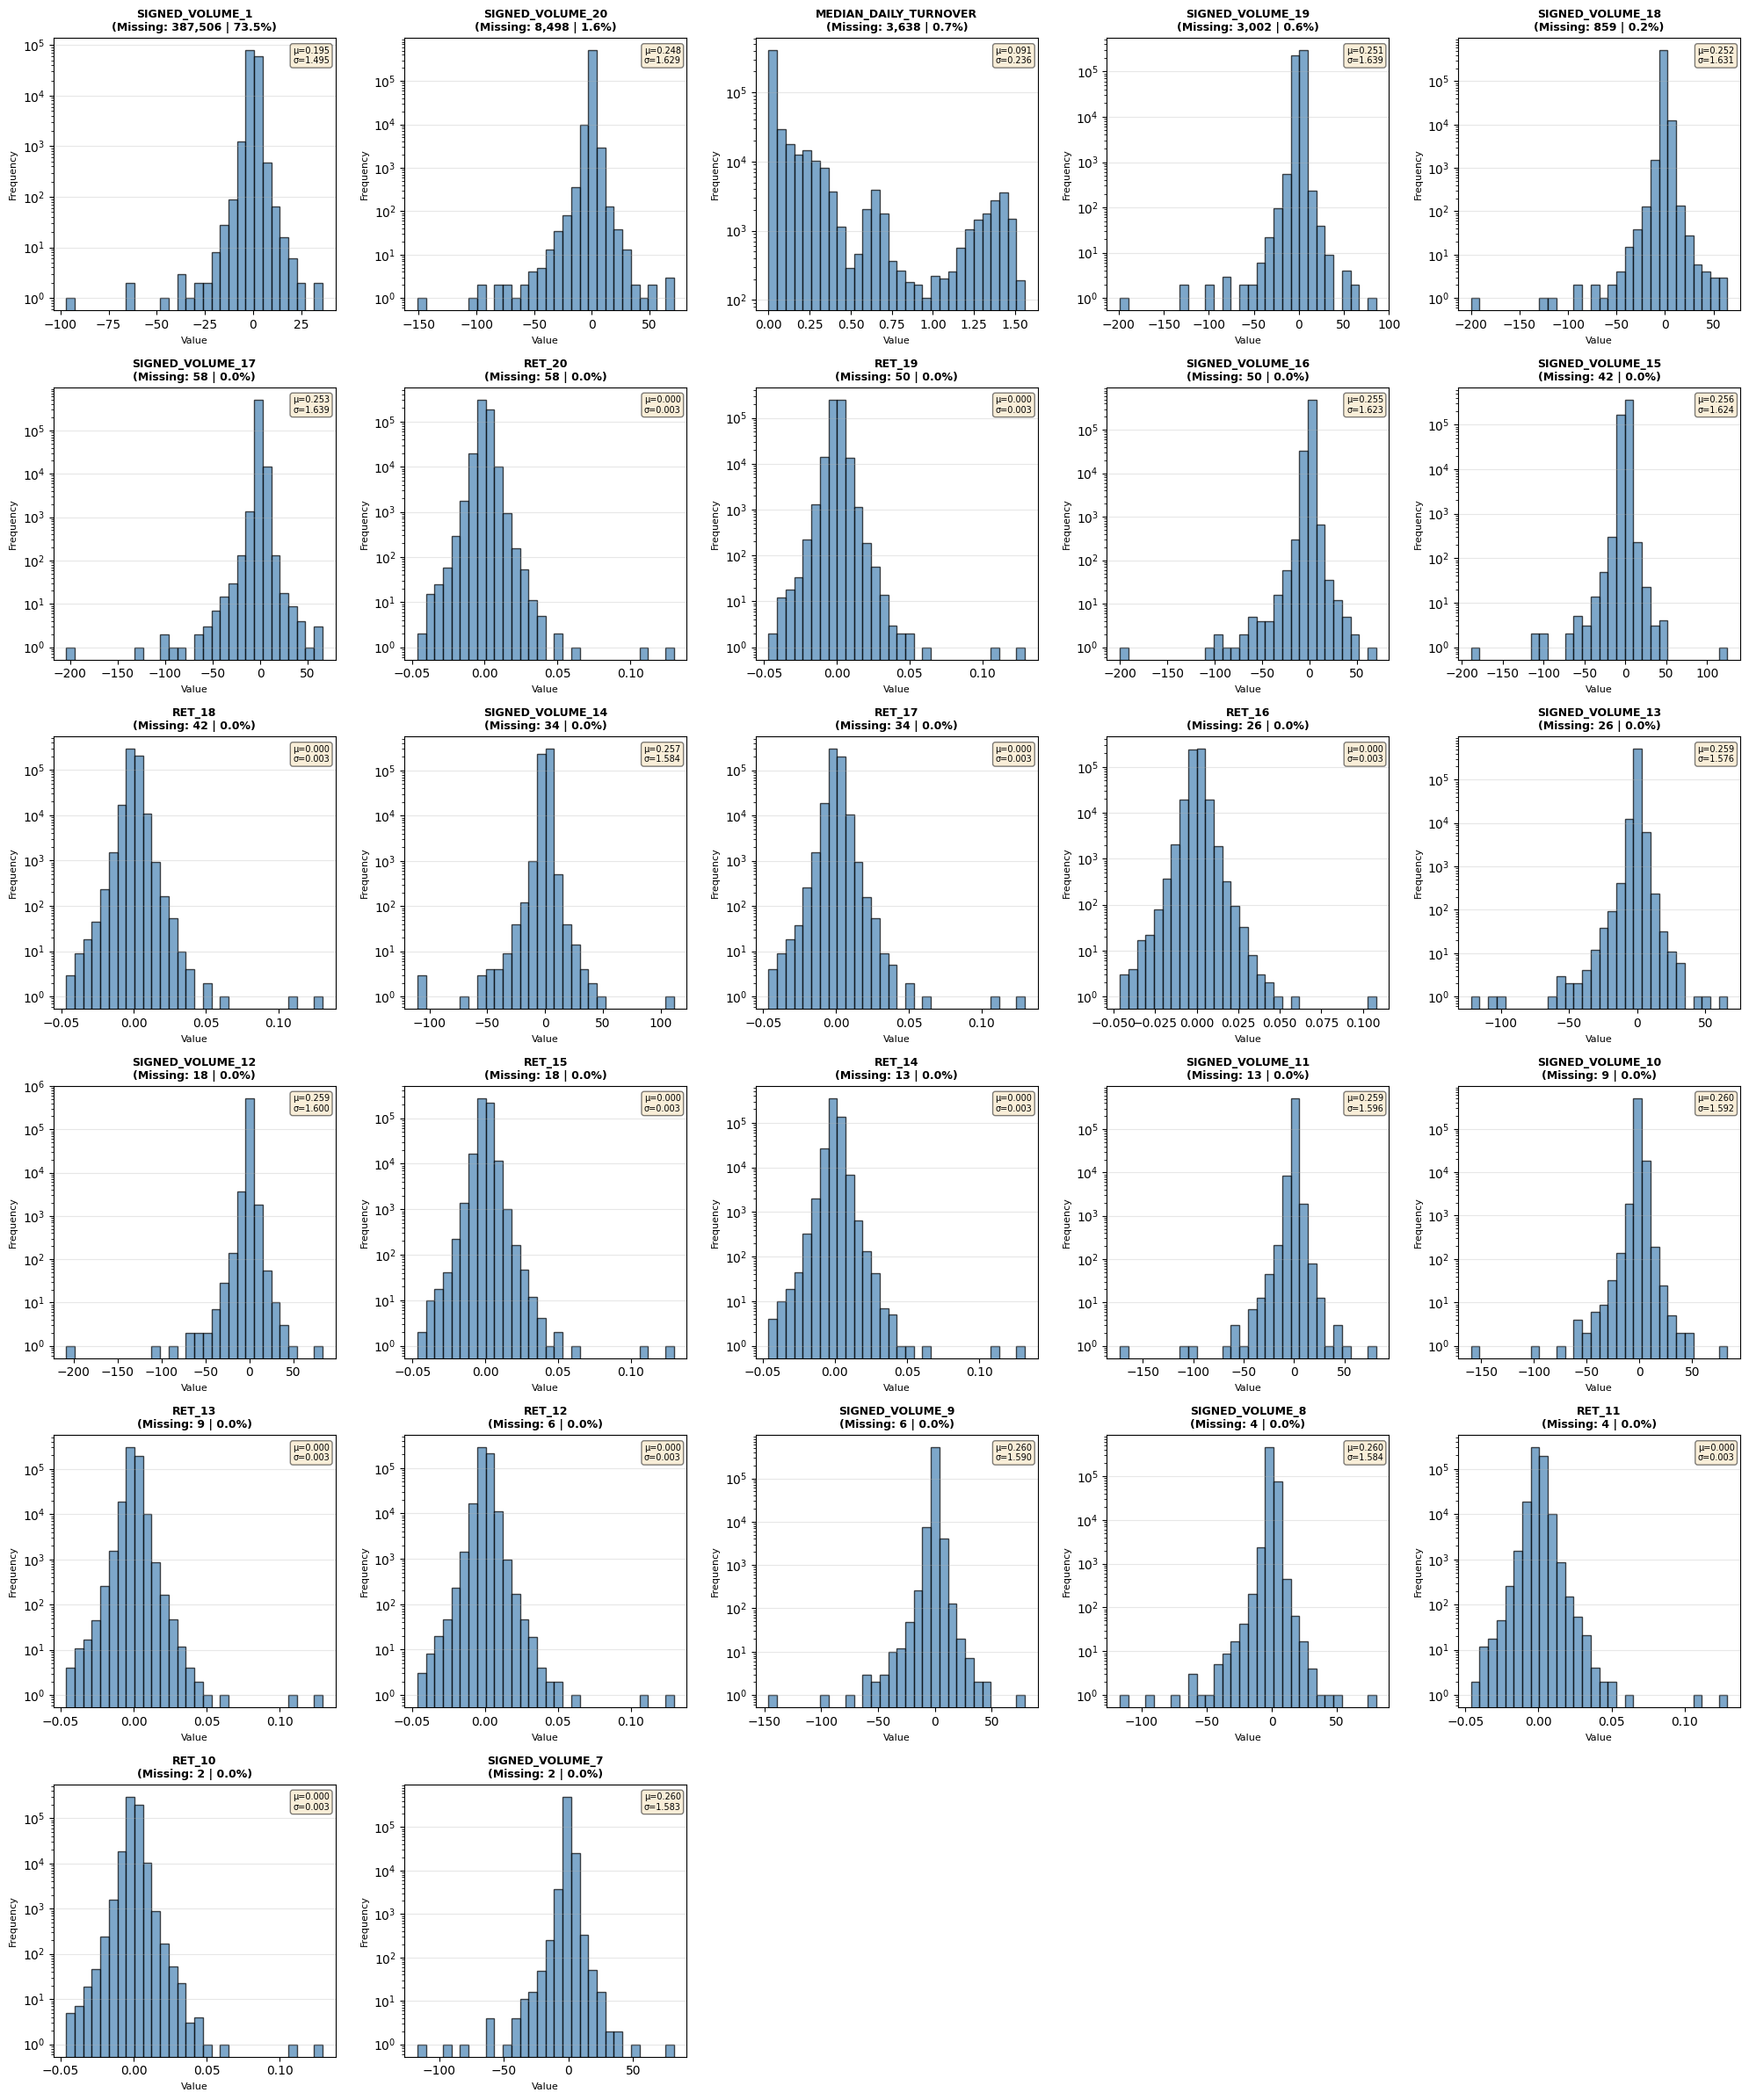


Total columns with missing data: 27


In [6]:
# Create histograms for columns with missing values to visualize data distribution
# Filter columns with missing values
missing_cols = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_cols) > 0:
    # Calculate number of rows needed (5 graphs per row)
    n_cols_to_plot = len(missing_cols)
    n_plots_per_row = 5
    n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))
    
    # Flatten axes array if needed
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    else:
        axes = axes.flatten()
    
    # Create a histogram for each column with missing values
    for idx, col in enumerate(missing_cols.index):
        ax = axes[idx]
        
        # Get data for this column (excluding NaN)
        data_col = data_train[col].dropna()
        
        # Create histogram
        ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Calculate statistics
        count_missing = missing_cols[col]
        count_present = len(data_col)
        pct_missing = (count_missing / len(data_train)) * 100
        
        # Add title with statistics
        ax.set_title(f'{col}\n(Missing: {count_missing:,} | {pct_missing:.1f}%)', 
                    fontsize=9, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        
        # Use logarithmic scale for better readability
        ax.set_yscale('log')
        
        # Add statistics text
        stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
               fontsize=7, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide unused subplots
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal columns with missing data: {n_cols_to_plot}")
else:
    print("No missing values found in the dataset.")

# NaN Analysis on Engineered Features

In [7]:
# Check for NaN in engineered features
RET_features = [f"RET_{i}" for i in range(1, 21)]

# Create engineered features (same as in ridge_regression.py)
for i in [3, 5, 10, 15, 20]:
    data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
    data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
    
    # Market-wide average performance and volatility on same day
    data_train[f"ALLOCATIONS_AVERAGE_PERF_{i}"] = data_train.groupby("TS")[
        f"AVERAGE_PERF_{i}"
    ].transform("mean")
    data_train[f"ALLOCATIONS_STD_PERF_{i}"] = data_train.groupby("TS")[
        f"STD_PERF_{i}"
    ].transform("mean")

# Check NaN in engineered features
engineered_features = (
    [f"AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"ALLOCATIONS_AVERAGE_PERF_{i}" for i in [3, 5, 10, 15, 20]]
    + [f"STD_PERF_{i}" for i in [20]]
    + [f"ALLOCATIONS_STD_PERF_{i}" for i in [20]]
)
nan_in_engineered = data_train[engineered_features].isnull().sum()

print("NaN count in engineered features:")
print(nan_in_engineered[nan_in_engineered > 0])
print(f"\nTotal NaN in engineered features: {nan_in_engineered.sum()}")

# Check which rows have NaN in original features
rows_with_nan = data_train[RET_features].isnull().any(axis=1).sum()
print(f"\nRows with at least one NaN in RET features: {rows_with_nan}")
print(f"Percentage: {(rows_with_nan / len(data_train)) * 100:.2f}%")

C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  data_train[f"AVERAGE_PERF_{i}"] = data_train[RET_features[:i]].mean(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  data_train[f"STD_PERF_{i}"] = data_train[RET_features[:i]].std(1)
C:\Users\vicca\AppData\Local\Temp\ipykernel_12664\1559570916.py:6: Pandas4Warnin

NaN count in engineered features:
Series([], dtype: int64)

Total NaN in engineered features: 0

Rows with at least one NaN in RET features: 58
Percentage: 0.01%


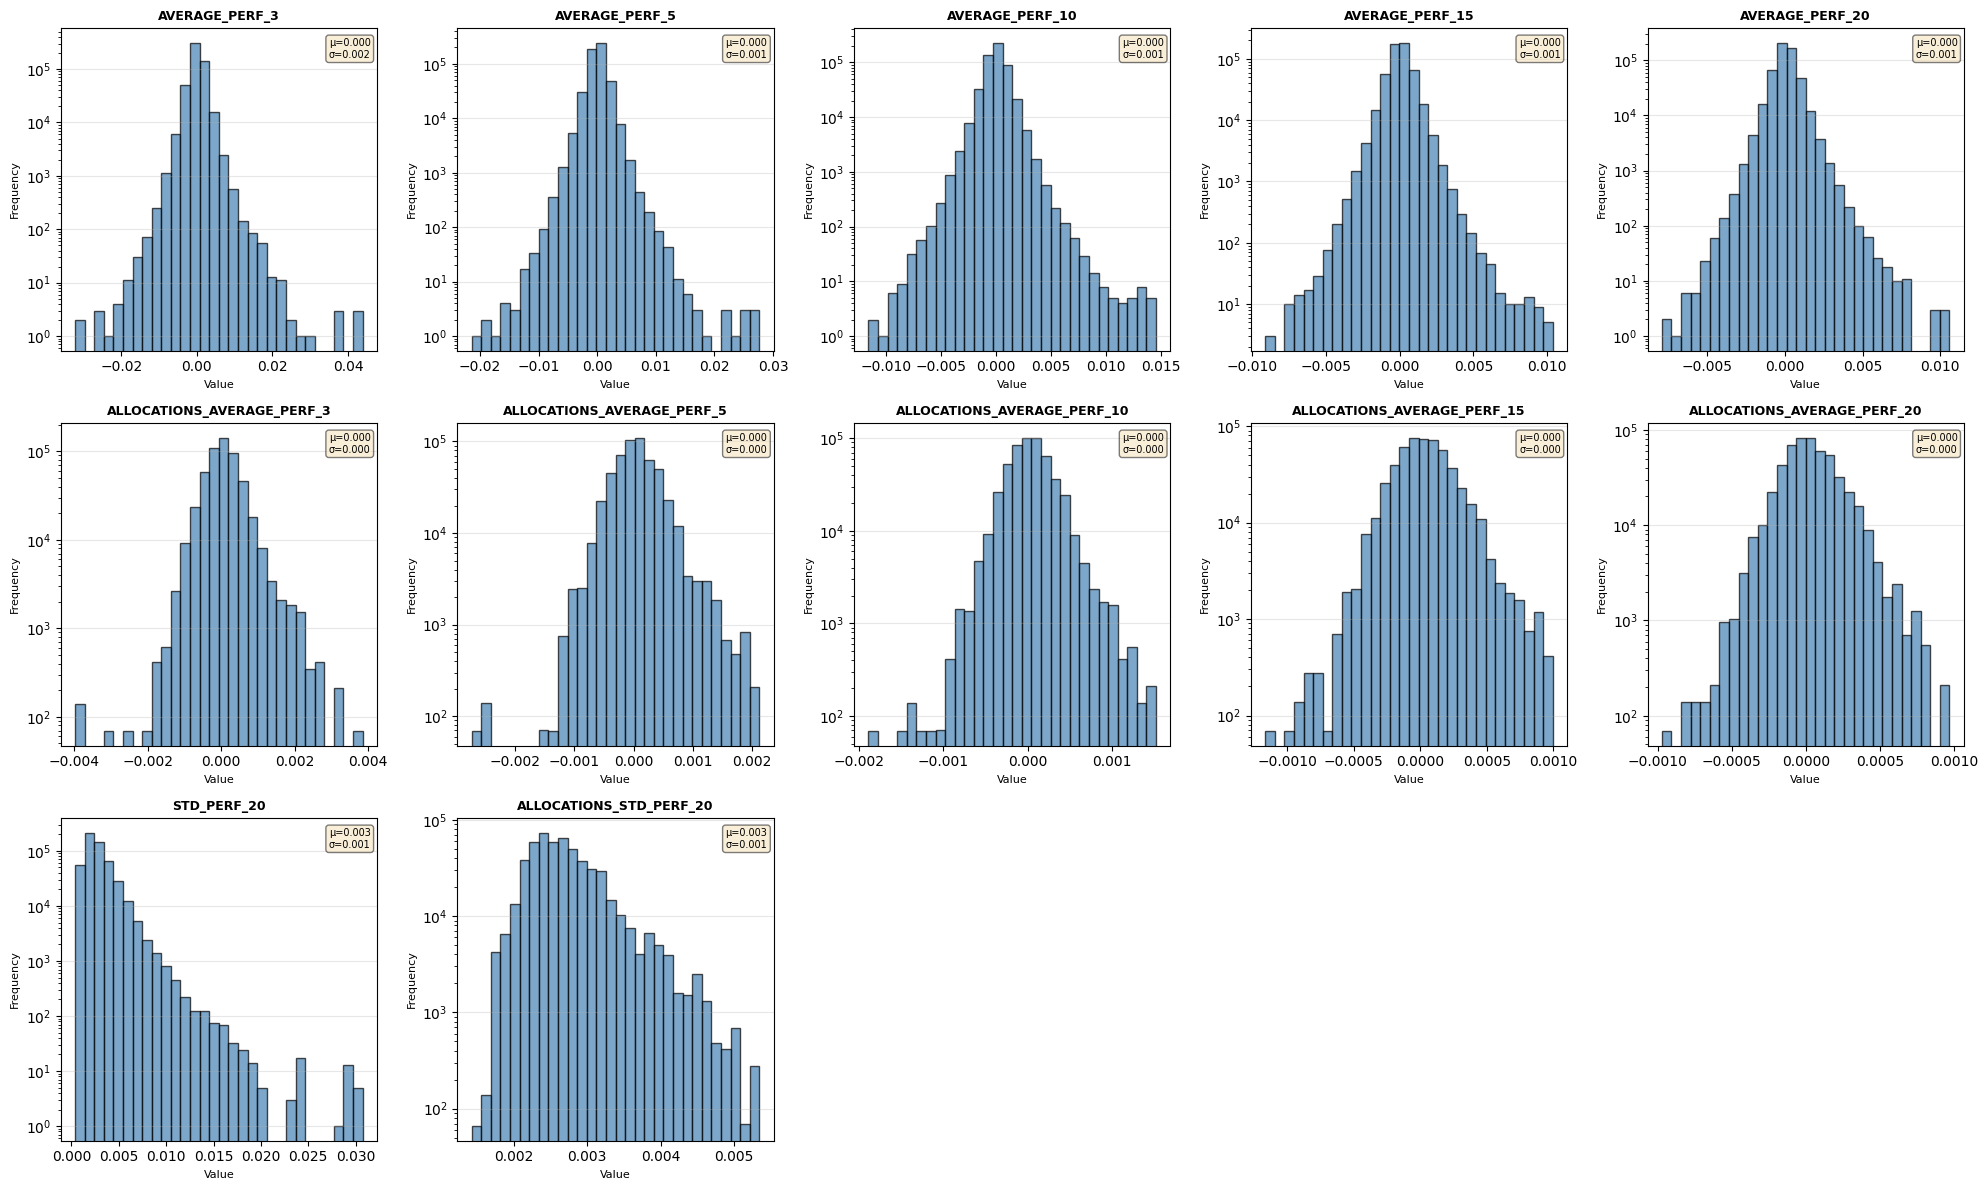

Engineered features visualization: 12 features displayed


In [8]:
# Visualize distributions of engineered features
# Calculate number of rows needed (5 graphs per row)
n_cols_to_plot = len(engineered_features)
n_plots_per_row = 5
n_rows = (n_cols_to_plot + n_plots_per_row - 1) // n_plots_per_row

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_plots_per_row, figsize=(20, 4 * n_rows))

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.flatten()

# Create a histogram for each engineered feature
for idx, col in enumerate(engineered_features):
    ax = axes[idx]
    
    # Get data for this column (excluding NaN - should be none as confirmed)
    data_col = data_train[col].dropna()
    
    # Create histogram
    ax.hist(data_col, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Add title
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Use logarithmic scale for better readability
    ax.set_yscale('log')
    
    # Add statistics text
    stats_text = f'μ={data_col.mean():.3f}\nσ={data_col.std():.3f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
           fontsize=7, verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplots
for idx in range(n_cols_to_plot, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Engineered features visualization: {n_cols_to_plot} features displayed")

coherent to use the median for almost all the data, except the standards deviations, we can use the peak of the curve for them, using the principal mode of the distribution (Kernel density estimation)

Maybe as an alternative to this, we can use for all data MICE (Multiple Imputation by chained equations)

## EDA - Statistiques Descriptives et Corrélations

In [15]:
import seaborn as sns
from scipy import stats

# Use data_train from previous cell and prepare X_train
X_train = data_train.drop(columns=['ROW_ID', 'TS', 'ALLOCATION', 'GROUP'])

print(f"Données chargées: {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Target shape: {y_train.shape}")

Données chargées: 527073 lignes, 61 colonnes
Target shape: (527073, 1)


In [16]:
# Statistiques descriptives complètes
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)

stats_df = pd.DataFrame({
    'Mean': X_train.mean(),
    'Std': X_train.std(),
    'Min': X_train.min(),
    'Max': X_train.max(),
    'Skewness': X_train.skew(),
    'Kurtosis': X_train.kurtosis(),
    'Missing %': (X_train.isnull().sum() / len(X_train) * 100).round(2)
})

print(stats_df.to_string())
print(f"\nTotal features: {len(X_train.columns)}")


STATISTIQUES DESCRIPTIVES
                                 Mean       Std           Min         Max  Skewness    Kurtosis  Missing %
RET_20                       0.000021  0.003102 -4.622569e-02    0.129840  0.122445   15.658126       0.01
RET_19                       0.000025  0.003089 -4.698683e-02    0.129343  0.181787   15.426985       0.01
RET_18                       0.000027  0.003082 -4.677892e-02    0.130503  0.178572   15.574769       0.01
RET_17                       0.000025  0.003075 -4.636841e-02    0.129712  0.182360   15.499966       0.01
RET_16                       0.000024  0.003065 -4.627304e-02    0.107983  0.041145    9.551736       0.00
RET_15                       0.000027  0.003061 -4.661937e-02    0.129469  0.186005   15.596066       0.00
RET_14                       0.000026  0.003059 -4.587277e-02    0.131424  0.191171   16.116575       0.00
RET_13                       0.000026  0.003056 -4.616847e-02    0.129362  0.179715   15.889576       0.00
RET_12     


ANALYSE SKEWNESS (Asymétrie)

Top 10 features avec Skewness POSITIVE (queue à droite):
MEDIAN_DAILY_TURNOVER      4.322450
STD_PERF_3                 3.099373
STD_PERF_5                 3.002151
STD_PERF_10                2.788871
STD_PERF_15                2.617103
STD_PERF_20                2.504463
ALLOCATIONS_STD_PERF_3     1.637352
ALLOCATIONS_STD_PERF_5     1.466944
ALLOCATIONS_STD_PERF_10    1.381631
ALLOCATIONS_STD_PERF_15    1.276790
dtype: float64

Top 10 features avec Skewness NÉGATIVE (queue à gauche):
SIGNED_VOLUME_10   -3.671384
SIGNED_VOLUME_1    -3.897994
SIGNED_VOLUME_11   -4.712712
SIGNED_VOLUME_20   -4.925758
SIGNED_VOLUME_15   -5.831602
SIGNED_VOLUME_12   -6.410861
SIGNED_VOLUME_18   -6.979930
SIGNED_VOLUME_16   -7.135661
SIGNED_VOLUME_17   -7.423726
SIGNED_VOLUME_19   -7.429370
dtype: float64


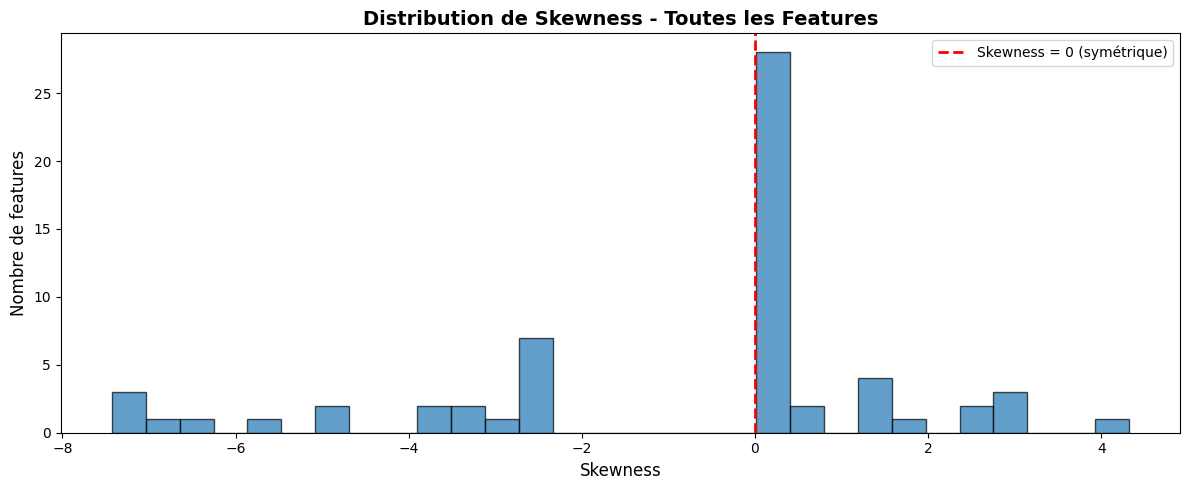


Skewness moyen: -0.8615
Nombre de features avec |Skewness| > 1: 31


In [17]:
# Analyse Skewness
print("\n" + "=" * 80)
print("ANALYSE SKEWNESS (Asymétrie)")
print("=" * 80)

skewness = X_train.skew().sort_values(ascending=False)
print("\nTop 10 features avec Skewness POSITIVE (queue à droite):")
print(skewness.head(10))

print("\nTop 10 features avec Skewness NÉGATIVE (queue à gauche):")
print(skewness.tail(10))

# Visualiser la distribution des skewness
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(skewness, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Skewness', fontsize=12)
ax.set_ylabel('Nombre de features', fontsize=12)
ax.set_title('Distribution de Skewness - Toutes les Features', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Skewness = 0 (symétrique)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSkewness moyen: {skewness.mean():.4f}")
print(f"Nombre de features avec |Skewness| > 1: {(skewness.abs() > 1).sum()}")


In [18]:
# Matrice de corrélation - Visualisation complète
print("\n" + "=" * 80)
print("MATRICE DE CORRÉLATION")
print("=" * 80)

# Calculer les corrélations
corr_matrix = X_train.corr()

# Afficher statistiques des corrélations
print(f"\nNombre total de paires de features: {len(X_train.columns) * (len(X_train.columns) - 1) // 2}")

# Corrélations fortes (> 0.7)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', ascending=False, key=abs)
    print(f"\nCorrélations fortes (|r| > 0.7): {len(strong_corr_df)}")
    print(strong_corr_df.to_string(index=False))
else:
    print(f"\nAucune corrélation forte (|r| > 0.7) trouvée")

# Corrélations modérées (0.5 - 0.7)
moderate_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if 0.5 <= abs(corr_matrix.iloc[i, j]) <= 0.7:
            moderate_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if moderate_corr:
    print(f"\nCorrélations modérées (0.5 < |r| <= 0.7): {len(moderate_corr)}")
    print(f"(affichage limité aux 10 premières)")
    moderate_corr_df = pd.DataFrame(moderate_corr).sort_values('Correlation', ascending=False, key=abs)
    print(moderate_corr_df.head(10).to_string(index=False))



MATRICE DE CORRÉLATION

Nombre total de paires de features: 1830

Corrélations fortes (|r| > 0.7): 28
                  Feature 1                   Feature 2  Correlation
    ALLOCATIONS_STD_PERF_15     ALLOCATIONS_STD_PERF_20     0.974808
                STD_PERF_15                 STD_PERF_20     0.965584
    ALLOCATIONS_STD_PERF_10     ALLOCATIONS_STD_PERF_15     0.959939
                STD_PERF_10                 STD_PERF_15     0.939721
    ALLOCATIONS_STD_PERF_10     ALLOCATIONS_STD_PERF_20     0.922472
     ALLOCATIONS_STD_PERF_5     ALLOCATIONS_STD_PERF_10     0.912401
     ALLOCATIONS_STD_PERF_3      ALLOCATIONS_STD_PERF_5     0.903942
                STD_PERF_10                 STD_PERF_20     0.901072
            AVERAGE_PERF_15             AVERAGE_PERF_20     0.871835
ALLOCATIONS_AVERAGE_PERF_15 ALLOCATIONS_AVERAGE_PERF_20     0.863713
     ALLOCATIONS_STD_PERF_5     ALLOCATIONS_STD_PERF_15     0.860730
                 STD_PERF_5                 STD_PERF_10     0.855936


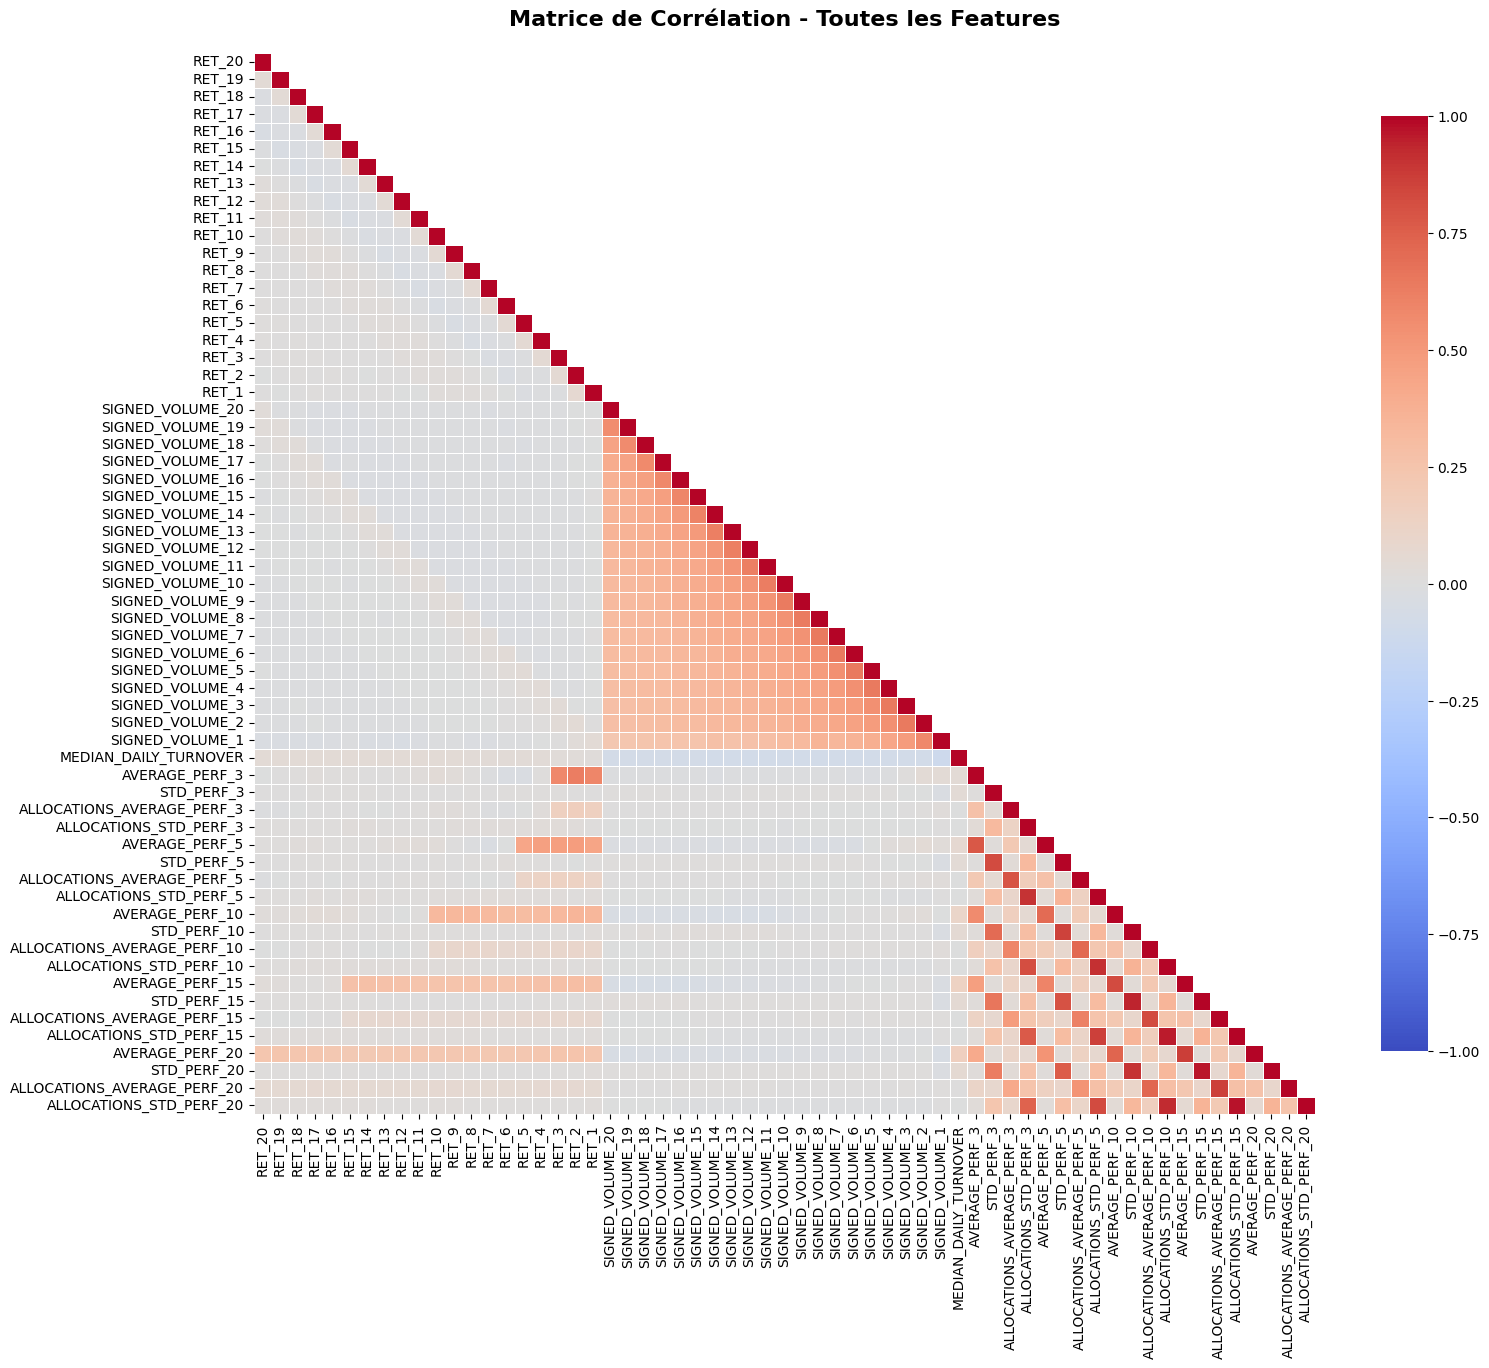

In [19]:
# Heatmap de corrélation (complète)
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matrice de Corrélation - Toutes les Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [20]:
# Résumé global
print("\n" + "=" * 80)
print("RÉSUMÉ GLOBAL")
print("=" * 80)

print(f"\n📊 Dataset:")
print(f"   Nombre de samples: {len(X_train):,}")
print(f"   Nombre de features: {len(X_train.columns)}")
print(f"   Nombre total de valeurs: {X_train.size:,}")
print(f"   Valeurs manquantes: {X_train.isnull().sum().sum():,} ({X_train.isnull().sum().sum() / X_train.size * 100:.2f}%)")

print(f"\n📈 Moyenne par feature:")
print(f"   Moyenne globale: {X_train.mean().mean():.6f}")
print(f"   Min: {X_train.mean().min():.6f}")
print(f"   Max: {X_train.mean().max():.6f}")

print(f"\n📐 Skewness:")
print(f"   Moyenne: {X_train.skew().mean():.4f}")
print(f"   Min (plus négative): {X_train.skew().min():.4f}")
print(f"   Max (plus positive): {X_train.skew().max():.4f}")
print(f"   Features presque symétriques (|skew| < 0.5): {(X_train.skew().abs() < 0.5).sum()}")
print(f"   Features modérément asymétriques (0.5 < |skew| < 1): {((X_train.skew().abs() >= 0.5) & (X_train.skew().abs() < 1)).sum()}")
print(f"   Features fortement asymétriques (|skew| >= 1): {(X_train.skew().abs() >= 1).sum()}")

print(f"\n🔗 Corrélations:")
print(f"   Corrélation moyenne (en valeur absolue): {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.4f}")
print(f"   Max corrélation (excl. diagonale): {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].max():.4f}")



RÉSUMÉ GLOBAL

📊 Dataset:
   Nombre de samples: 527,073
   Nombre de features: 61
   Nombre total de valeurs: 32,151,453
   Valeurs manquantes: 404,027 (1.26%)

📈 Moyenne par feature:
   Moyenne globale: 0.085181
   Min: 0.000021
   Max: 0.260059

📐 Skewness:
   Moyenne: -0.8615
   Min (plus négative): -7.4294
   Max (plus positive): 4.3225
   Features presque symétriques (|skew| < 0.5): 29
   Features modérément asymétriques (0.5 < |skew| < 1): 1
   Features fortement asymétriques (|skew| >= 1): 31

🔗 Corrélations:
   Corrélation moyenne (en valeur absolue): 0.0805
   Max corrélation (excl. diagonale): 0.9748
